<a href="https://colab.research.google.com/github/mohanraju2002/text_to_imgg/blob/main/text_to_img.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **METHOD-1**

In [ ]:
!pip install diffusers transformers accelerate safetensors

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt

# Load photorealistic model (better for realistic images)
model_id = "runwayml/stable-diffusion-v1-5"  # Good base, or try "dreamlike-art/dreamlike-photoreal-2.0"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    safety_checker=None,
    requires_safety_checker=False
)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)
print(f"Using device: {device}")

# Photorealistic prompt with detailed description

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cuda


  0%|          | 0/50 [00:00<?, ?it/s]

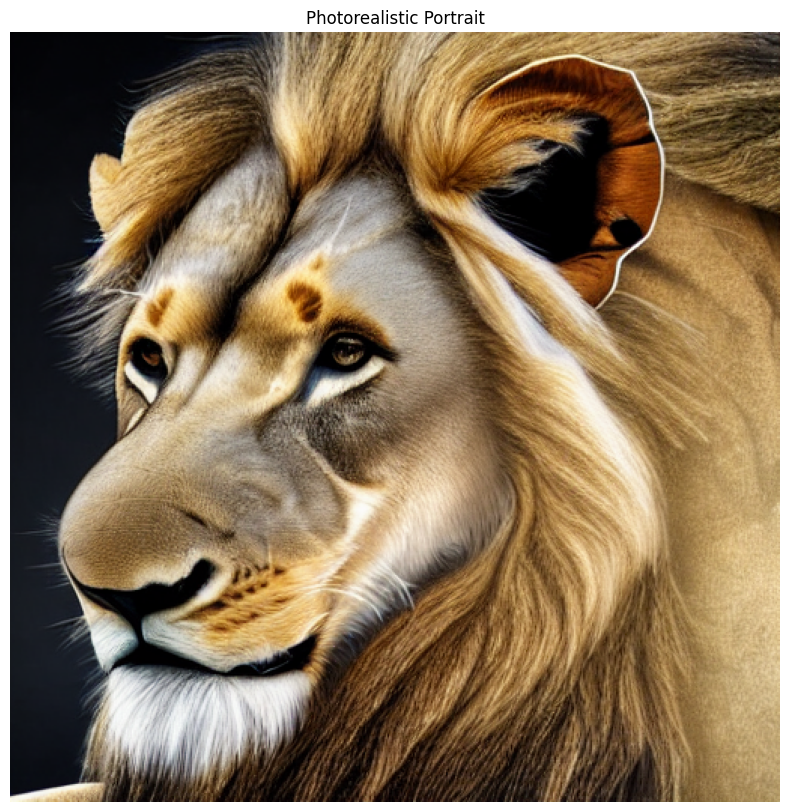

✅ Realistic image generated and saved as realistic_portrait.png


In [ ]:

prompt = "A realistic lion sitting on a throne"

# Negative prompt to avoid artifacts
# negative_prompt = (
#     "cartoon, anime, sketch, painting, blurry, low quality, deformed, ugly, extra limbs, "
#     "poorly drawn face, bad anatomy, watermark, text"
# )

# Generate with optimized settings for realism
with torch.autocast(device):
    image = pipe(
        prompt,
        # negative_prompt=negative_prompt,
        num_inference_steps=50,  # More steps = better quality
        guidance_scale=7.5,      # Higher = follows prompt more closely
        height=512,
        width=512
    ).images[0]

# Display & save
image.save("realistic_portrait.png")
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('off')
plt.title("Photorealistic Portrait")
plt.show()
print("✅ Realistic image generated and saved as realistic_portrait.png")


# **METHOD-2**

In [ ]:
import torch
from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
# Load improved model (safety checker off)
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    safety_checker=None,
    requires_safety_checker=False
)

# Upgrade to Euler scheduler for better quality
pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)
pipe.enable_attention_slicing()  # Memory optimization for low VRAM
print(f"Using device: {device}")

  0%|          | 0/30 [00:00<?, ?it/s]

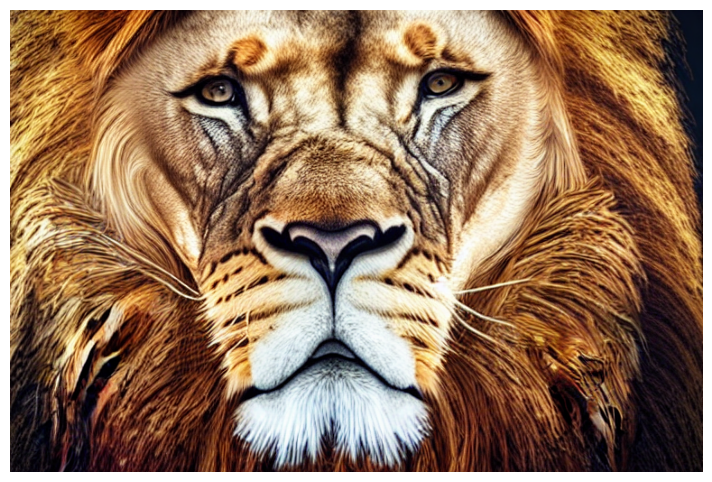

✅ Image generated and saved as ai_image.png


In [ ]:
prompt = "A realistic lion sitting on a throne"
# negative_prompt = "blurry, low quality, deformed, ugly, extra limbs, poorly drawn face, bad anatomy, watermark, text"  # Improves output quality

# Generate with enhancements
with torch.autocast(device):
    image = pipe(
        prompt,
        # negative_prompt=negative_prompt,
        num_inference_steps=30,  # More steps for detail
        guidance_scale=7.5,
        height=512,
        width=768  # Landscape for road scene
    ).images[0]

# Display & save
image.save("ai_dog_rain_new.png")
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis('off')
plt.show()
print("✅ Image generated and saved as ai_image.png")
